# Import the Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [4]:
#Loading the datasets
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
#Adding target column
df['target']=iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print(df['target'].unique)

<bound method Series.unique of 0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64>


# Exploratory Data Analysis

In [7]:
print(df.shape)
print(df.info())
print(df.describe())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.30000

#### Found out that there are 5 columns and 150 rows or entries in the dataset

In [8]:
#Checking Null Values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


#### Finding out that there are no Null values in the Iris Dataset

In [9]:
#Creating a Labelled column for species of flowers so that target is clear
df.loc[:,"Species name"] = None
df.loc[df['target'] == 0,"Species name"] = "Setosa"
df.loc[df['target'] == 1,"Species name"] = "Versicolor"
df.loc[df['target'] == 2,"Species name"] = "Virginica"
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target Species name  
0       0       Setosa  
1       0       Setosa  
2       0       Setosa  
3       0       Setosa  
4       0       Setosa  


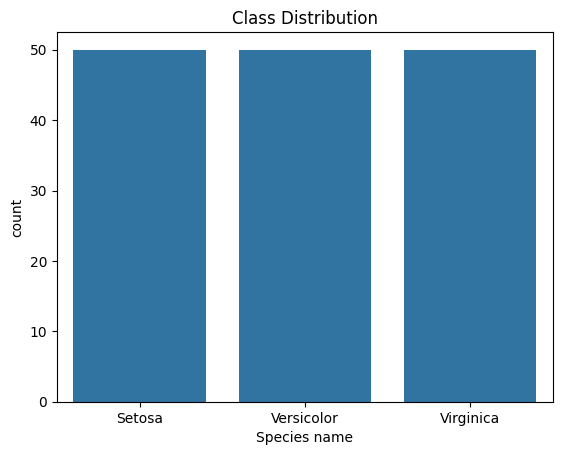

In [28]:
#Visualise Class Distribution
sns.countplot(x="Species name",data=df)
plt.title("Class Distribution")
plt.savefig("../Images/class_distribution.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observation:
##### The Iris Dataset is Balanced with 50 samples of each flower classes. This hepls in fair model training and reduces class bias.

### Heatmap for Correlation

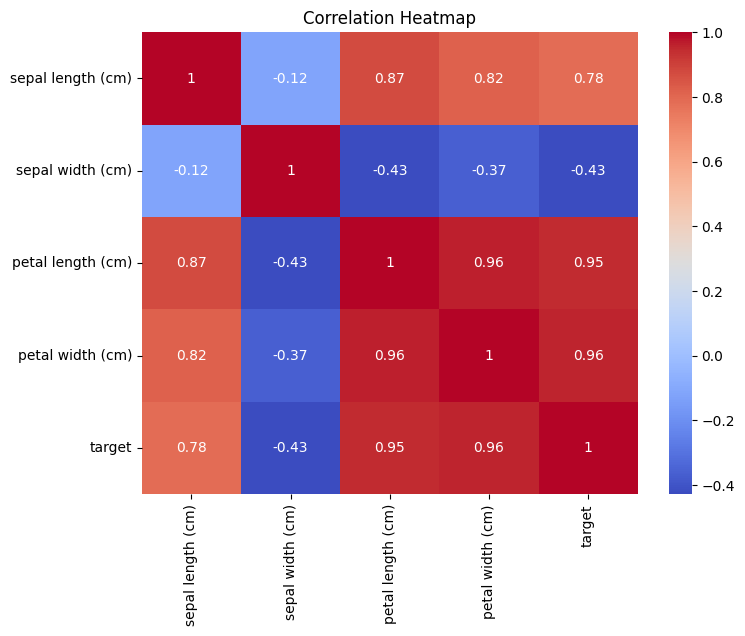

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=["number"]).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("../Images/heatmap_correalation.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observations:
##### 1. Petal Length and petal width have very strong positive correlation(0.96). This means both features increase together and are highly important for classification.
##### 2. Sepal Length shows positive correlation with petal features ranging between 8 to 9.
##### 3. Sepal width has weak negative correlation with other features. So, it contributes less than petal dimensions.
##### 4. Target variable is highly correlated with petal features. This indicates that petal-related features are most useful for predicting Iris flower species.

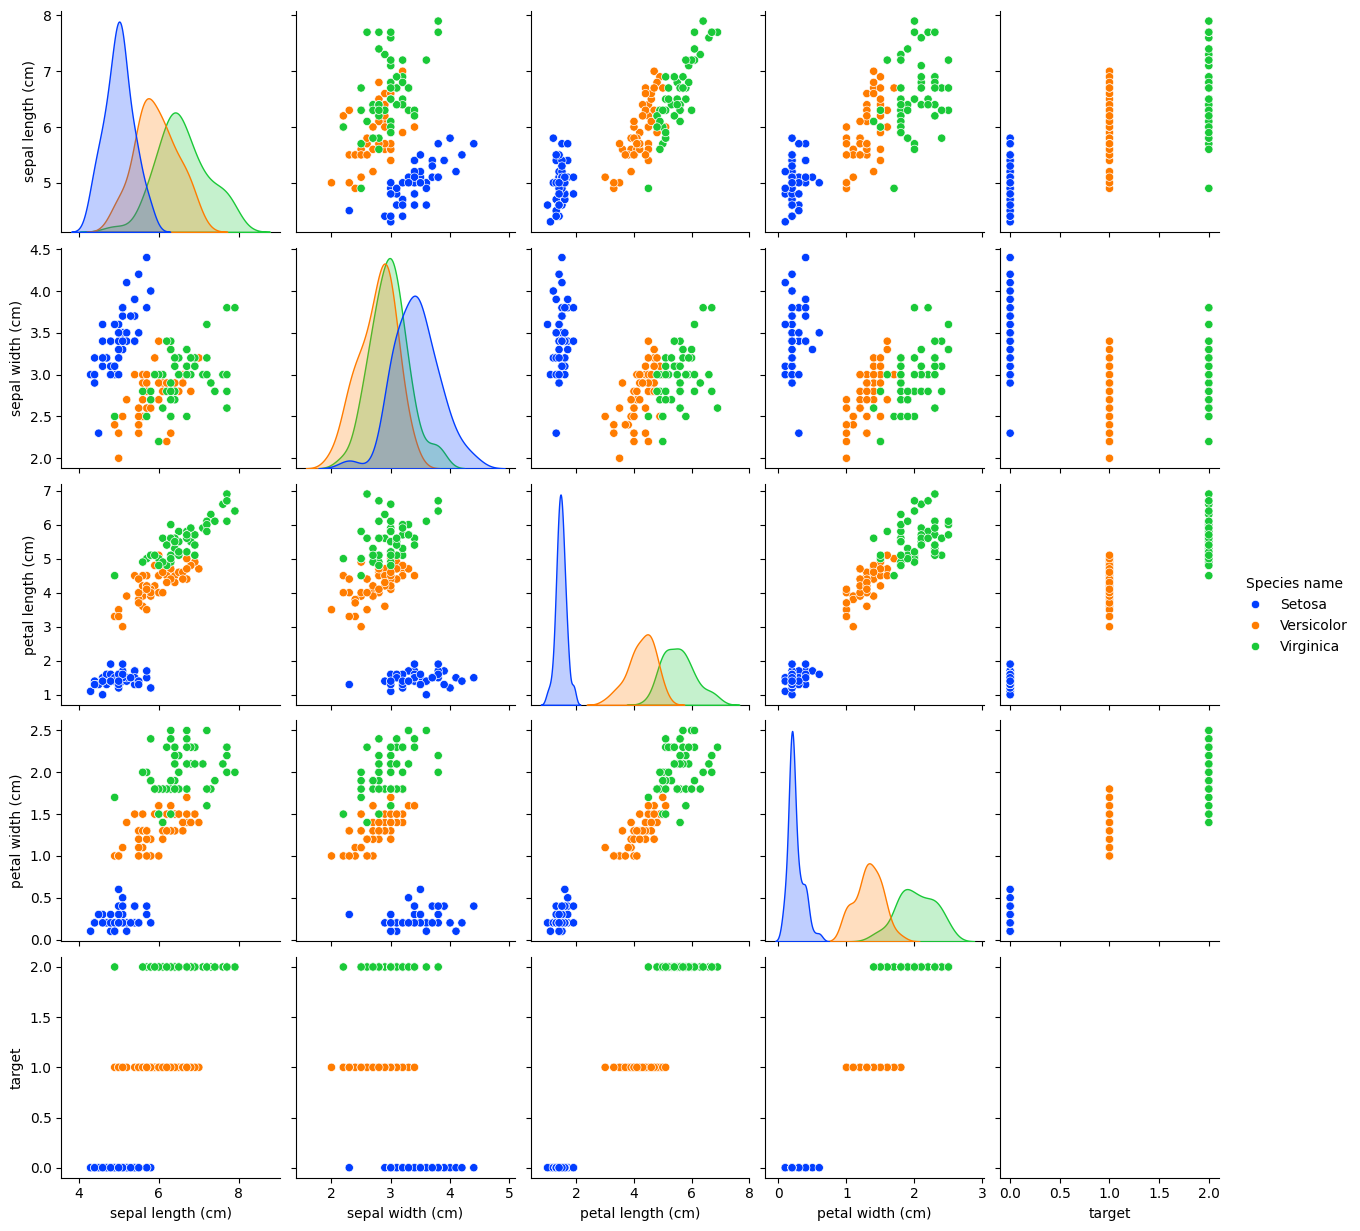

In [30]:
#Visualise Pairplot 
sns.pairplot(df,hue="Species name",palette="bright")
plt.savefig("../Images/pairplot.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observations:
##### 1. Versicolor and Virginica species show slight overlap in some features, especially in sepal dimensions.
##### 2. Setosa species is clearly separable from the other two species. It's petal features values are smaller.
##### 3. Strong Positive relationship can be observed between petal features.
##### 4. The Dataset is suitable for classification tasks because the classes show distinguishable feature patterns.

### Data Preprocessing

In [13]:
#Train-Test Split
from sklearn.model_selection import train_test_split
x = df.drop(columns=['target','Species name'])
y = df['target']
#Taking 80% for train and rest 20% for test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Data Shape:",x_train.shape)
print("Testing Data Shape:",x_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


### Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
#Standard scaler helps to standardize each feature making mean=0 and varience=1
scaler = StandardScaler()
#now we need to compute it in training data so that no data leakage is there
x_train = scaler.fit_transform(x_train)
#now we need to apply parameters on test data
x_test = scaler.transform(x_test)
#Getting the 5 rows 
print(x_train[:5])

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]


### One-Hot Encoding

In [15]:
# By this, we will convert categorical data to the binary vectors and lead to improved model performance
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


# Neural Network Model Creation

In [16]:
#Import the libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,Adam

## Creating Architecture of Neural Network

In [17]:
def create_model(optimizer):
    model = Sequential()
    #First Hidden Layer : having input_shape=4 because having 4 features in dataset
    model.add(Input(shape=(4,)))

    #Hidden Layer
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8,activation='relu'))

    #Output Layer : having 3 output which is as flower species name
    model.add(Dense(3,activation='softmax'))

    #compile model
    model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return model

## Gradient Descent Model

In [18]:
gdm_optimizer = SGD(learning_rate=0.01)
gd_model = create_model(gdm_optimizer)
gdm_history = gd_model.fit(x_train,y_train_cat,epochs=50,batch_size=x_train.shape[0],validation_split=0.2,verbose=1)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1458 - loss: 1.4067 - val_accuracy: 0.0000e+00 - val_loss: 1.2994
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.1458 - loss: 1.3854 - val_accuracy: 0.0000e+00 - val_loss: 1.2849
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.1458 - loss: 1.3649 - val_accuracy: 0.0000e+00 - val_loss: 1.2712
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.1458 - loss: 1.3454 - val_accuracy: 0.0417 - val_loss: 1.2580
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.1667 - loss: 1.3269 - val_accuracy: 0.0833 - val_loss: 1.2453
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1771 - loss: 1.3094 - val_accuracy: 0.0833 - val_loss: 1.2329
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.1771 - loss: 1.2925 - val_accuracy: 0.0833 - val_loss: 1.2210
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.1667 - loss: 1.2766 - val_accuracy: 0.0833 - 

## Stochastic Gradient Descent Model

In [19]:
sgd_optimizer = SGD(learning_rate=0.01)
sgd_model = create_model(sgd_optimizer)
sgd_history = sgd_model.fit(x_train,y_train_cat,epochs=50,batch_size=1,validation_split=0.2,verbose=1)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3958 - loss: 1.0743 - val_accuracy: 0.8333 - val_loss: 0.8927
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7812 - loss: 0.9189 - val_accuracy: 0.8750 - val_loss: 0.7533
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8333 - loss: 0.8072 - val_accuracy: 0.9167 - val_loss: 0.6450
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8438 - loss: 0.7090 - val_accuracy: 0.9167 - val_loss: 0.5528
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8646 - loss: 0.6303 - val_accuracy: 0.9167 - val_loss: 0.4863
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8646 - loss: 0.5659 - val_accuracy: 0.9167 - val_loss: 0.4316
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.5042 - val_accuracy: 0.9167 - val_loss: 0.3979
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8646 - loss: 0.4618 - val_accuracy: 0.9167 - val_loss:

## Mini-Batch Gradient Descent Model

In [20]:
mbgd_optimizer = SGD(learning_rate=0.01)
mbgd_model = create_model(mbgd_optimizer)
mbgd_history = mbgd_model.fit(x_train,y_train_cat,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.3229 - loss: 1.0778 - val_accuracy: 0.2083 - val_loss: 1.1334
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3750 - loss: 1.0322 - val_accuracy: 0.2083 - val_loss: 1.0929
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3854 - loss: 0.9925 - val_accuracy: 0.2500 - val_loss: 1.0570
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4479 - loss: 0.9553 - val_accuracy: 0.3333 - val_loss: 1.0248
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5208 - loss: 0.9224 - val_accuracy: 0.5000 - val_loss: 0.9956
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5833 - loss: 0.8909 - val_accuracy: 0.5833 - val_loss: 0.9688
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6458 - loss: 0.8627 - val_accuracy: 0.6667 - val_loss: 0.9443
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6979 - loss: 0.8376 - val_accuracy: 0.6667 - val_loss: 0.9215

## Adam Optimizer Model

In [21]:
adam = create_model(Adam())
adam_history = adam.fit(x_train,y_train_cat,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.6146 - loss: 0.9820 - val_accuracy: 0.7083 - val_loss: 0.9419
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.6979 - loss: 0.9369 - val_accuracy: 0.7083 - val_loss: 0.9107
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7188 - loss: 0.8924 - val_accuracy: 0.8750 - val_loss: 0.8812
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8229 - loss: 0.8550 - val_accuracy: 0.9167 - val_loss: 0.8550
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8229 - loss: 0.8223 - val_accuracy: 0.9167 - val_loss: 0.8287
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8229 - loss: 0.7894 - val_accuracy: 0.8750 - val_loss: 0.8053
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8125 - loss: 0.7616 - val_accuracy: 0.8750 - val_loss: 0.7815
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8125 - loss: 0.7305 - val_accuracy: 0.8750 - val_loss: 0.759

# Model Evaluation

In [22]:
gd_loss, gd_acc = gd_model.evaluate(x_test,y_test_cat,verbose=0)
sgd_loss, sgd_acc = sgd_model.evaluate(x_test,y_test_cat,verbose=0)
mbgd_loss, mbgd_acc = mbgd_model.evaluate(x_test,y_test_cat,verbose=0)
adam_loss, adam_acc = adam.evaluate(x_test,y_test_cat,verbose=0)

print("Gradient Descent Accuracy: ",gd_acc)
print("SGD Accuracy: ",sgd_acc)
print("Mini-Batch GD Accuracy: ",mbgd_acc)
print("Adam Accuracy: ",adam_acc)

Gradient Descent Accuracy:  0.7666666507720947
SGD Accuracy:  0.9666666388511658
Mini-Batch GD Accuracy:  0.8333333134651184
Adam Accuracy:  0.8999999761581421


## Accuracy Comparison

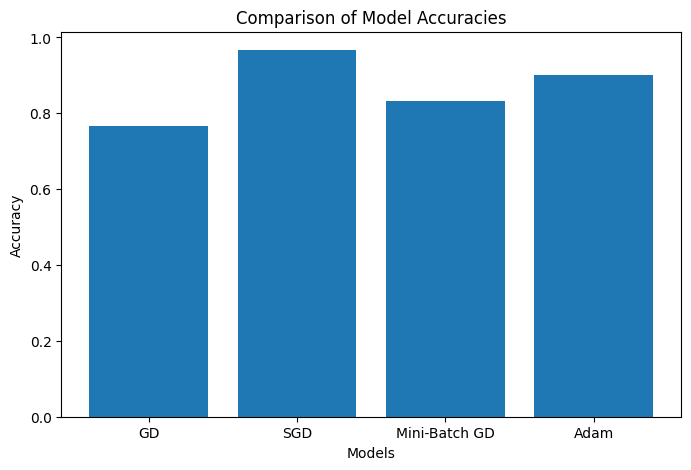

In [31]:
models = ['GD','SGD','Mini-Batch GD','Adam']
accuracy = [gd_acc,sgd_acc,mbgd_acc,adam_acc]

plt.figure(figsize=(8,5))
plt.bar(models,accuracy)

plt.title("Comparison of Model Accuracies")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.savefig("../Images/model_accuracy_comparison.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observations:
##### 1. SGD model has highest accuracy which is 100% accurate as the weights are getting updating after every training sample. 
##### 2. The Dataset is small so it overperforms well than Adam optimizer. 

## Comparison of Training Accuracy

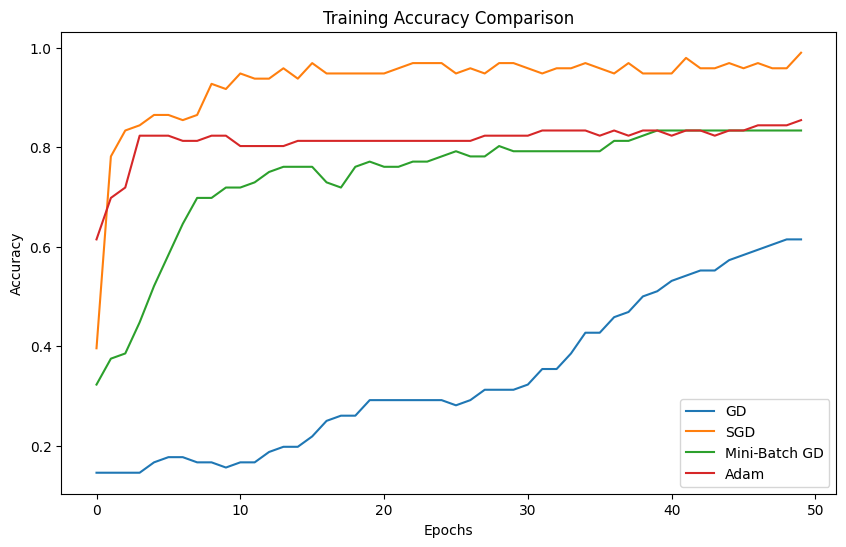

In [32]:
plt.figure(figsize=(10,6))

plt.plot(gdm_history.history['accuracy'],label='GD')
plt.plot(sgd_history.history['accuracy'],label='SGD')
plt.plot(mbgd_history.history['accuracy'],label='Mini-Batch GD')
plt.plot(adam_history.history['accuracy'],label='Adam')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.savefig("../Images/lineplot_accuracy.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observations:
##### 1. Gradient Descent showed slowest convergence because weights are updated once.
##### 2. Stochastic Gradient Descent And Adam optimizer showed faster learning and reached highest accuracy.
##### 3. Mini-Batch Gradient Descent showed stable and balanced learning behaviour.

## Comparison of Loss Curves

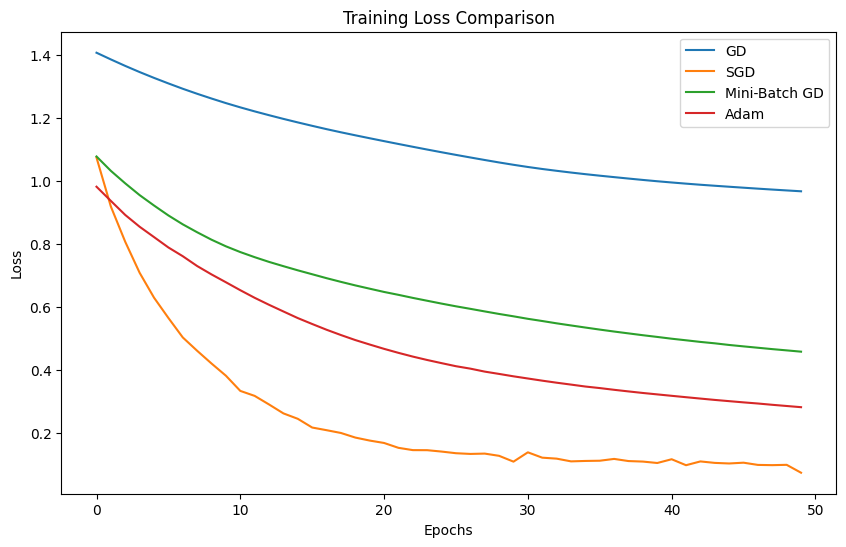

In [33]:
plt.figure(figsize=(10,6))

plt.plot(gdm_history.history['loss'],label='GD')
plt.plot(sgd_history.history['loss'],label='SGD')
plt.plot(mbgd_history.history['loss'],label='Mini-Batch GD')
plt.plot(adam_history.history['loss'],label='Adam')

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.savefig("../Images/lineplot_loss.png",bbox_inches='tight',dpi=300)
plt.show()

#### Observations:
##### 1. In SGD, Loss decreases very rapidly in first few epochs. It indicates faster convergence than rest of optimizers.
##### 2. In Adam, Loss decreases smoothly and consistently. It indicates balanced speed and stability.
##### 3. In Mini-Batch GD, Loss decreases steadily and more stable than SGD. It is slower than Adam and SGD.
##### 4. In GD, Loss decreases very slowly and after these loss remains high. It indicates slow convergence.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


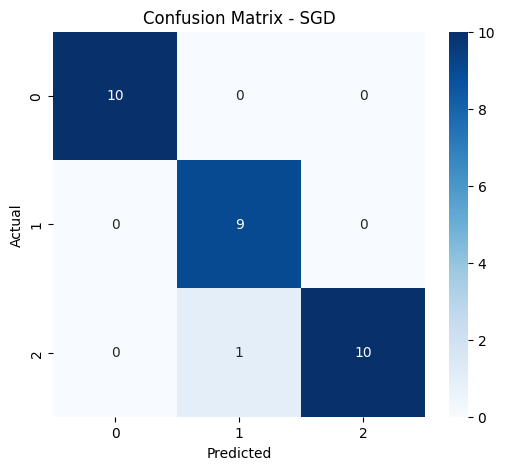

In [34]:
from sklearn.metrics import confusion_matrix

y_pred = np.argmax(sgd_model.predict(x_test),axis=1)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix - SGD")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Images/Confusion_matrix.png",bbox_inches='tight',dpi=300)
plt.show()

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



#### Confusion Matrix Analysis
##### The Confusion matrix indicates model has classified most samples correctly.
##### Class 0 and Class 2 has acheived highest and Class 1 has misclassified compared to both. 
##### The model has achieved an overall accuracy of 97% which depicts the effectiveness of backpropogation of neural networks.

## Overall Conclusion:
### This project demostrates the implemetation of Backpropagation in Neural Networks using optimizers Gradient Descent, Stochastic Gradient Descent, Mini-Batch Gradient Descent and Adam optimizer.
### The Iris Dataset was used for multiclass classification. Exploratory Data Analysis(EDA) was performed to understand features and correlations between them.
### The experimetal result show that Stochastic Gradient Descent shows high accuracy, Gradient Descent shows slowest learning behaviour, Mini-Batch Gradient Descent shows stability and Adam show efficient convergence.
### During testing the model, SGD shows highest accuracy of 97% test accuracy.
### This project successfully demostrates how backpropogation and optimization algorithms influence neural networks training and prediction performance.